In [4]:
# Install the Earth Engine Python library
# !pip install earthengine-api
# !pip install folium

import os
import ee
# import folium
import pandas as pd
import matplotlib.pyplot as plt

# Authenticate. This should only be necessary once. I ran the script in debug mode first, and authentication involved a visit of an external web site, generation of a token, and copy/paste of this in VS Code.
# ee.Authenticate()

# Specify data sources
collections = {
    'COPERNICUS/S5P/NRTI/L3_AER_AI': {
        'start': '2018-07-10',
        # 'start': '2024-05-10',
        'end': '2024-05-31', 
        'variables': ['absorbing_aerosol_index', 
                      ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_NRTI_L3_AER_AI'
    },
    'COPERNICUS/S5P/OFFL/L3_AER_AI': {
        'start': '2018-07-10',
        # 'start': '2024-05-10',
        'end': '2024-05-31', 
        'variables': ['absorbing_aerosol_index', 
                      ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_OFFL_L3_AER_AI'
    },
    'COPERNICUS/S5P/NRTI/L3_CO': {
        'start': '2018-11-22',
        'end': '',
        'variables': ['CO_column_number_density',
                      'H2O_column_number_density',
                      'cloud_height',
                      'sensor_altitude',
                      'sensor_azimuth_angle',
                      'sensor_zenith_angle',
                      'solar_azimuth_angle',
                      'solar_zenith_angle'],
        'description': '',
    }, 
    'COPERNICUS/S5P/OFFL/L3_CO': {
        'start': '2018-07-10',
        'end': '2024-05-31',
        'variables': ['CO_column_number_density',
                      'H2O_column_number_density',
                      'cloud_height',
                    #   'sensor_altitude',
                    #   'sensor_azimuth_angle',
                    #   'sensor_zenith_angle',
                    #   'solar_azimuth_angle',
                    #   'solar_zenith_angle',
                    ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_OFFL_L3_CO',
    },
    'COPERNICUS/S5P/NRTI/L3_NO2': {
        'start': '2018-07-10',
        'end': '2024-05-31',
        'variables': ['NO2_column_number_density',
                      'tropospheric_NO2_column_number_density',
                      'stratospheric_NO2_column_number_density',
                      'NO2_slant_column_number_density',
                      'tropopause_pressure',
                      'absorbing_aerosol_index',
                      'cloud_fraction',
                    #   'sensor_altitude',
                    #   'sensor_azimuth_angle',
                    #   'sensor_zenith_angle',
                    #   'solar_azimuth_angle',
                    #   'solar_zenith_angle',
                      ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_NRTI_L3_NO2',
    }, 
    'COPERNICUS/S5P/OFFL/L3_NO2': {
        'start': '2018-07-10',
        'end': '2024-05-31',
        'variables': ['NO2_column_number_density',
                      'tropospheric_NO2_column_number_density',
                      'stratospheric_NO2_column_number_density',
                      'NO2_slant_column_number_density',
                      'tropopause_pressure',
                      'absorbing_aerosol_index',
                      'cloud_fraction',
                    #   'sensor_altitude',
                    #   'sensor_azimuth_angle',
                    #   'sensor_zenith_angle',
                    #   'solar_azimuth_angle',
                    #   'solar_zenith_angle',
                      ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_OFFL_L3_NO2',
    }, 
    'COPERNICUS/S5P/NRTI/L3_O3': {
        'start': '2018-07-10',
        'end': '2024-05-31',
        'variables': ['O3_column_number_density',
                      'O3_effective_temperature',
                      'cloud_fraction',
                    #   'sensor_azimuth_angle',
                    #   'sensor_zenith_angle',
                    #   'solar_azimuth_angle',
                    #   'solar_zenith_angle',
                      ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_NRTI_L3_O3',
    }, 
    'COPERNICUS/S5P/OFFL/L3_O3': {
        'start': '2018-09-08',
        'end': '2024-05-31',
        'variables': ['O3_column_number_density',
                      'O3_effective_temperature',
                      'cloud_fraction',
                    #   'sensor_azimuth_angle',
                    #   'sensor_zenith_angle',
                    #   'solar_azimuth_angle',
                    #   'solar_zenith_angle',
                      ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_OFFL_L3_O3',
    }, 
    'COPERNICUS/S5P/OFFL/L3_O3_TCL': {
        'start': '2018-04-30',
        'end': '2024-05-31',
        'variables': ['ozone_tropospheric_mixing_ratio',
                      'ozone_tropospheric_mixing_ratio_precision',
                      'ozone_tropospheric_vertical_column','ozone_tropospheric_vertical_column_precision',
                       'qa_value'],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_OFFL_L3_O3',
    }, 
    'COPERNICUS/S5P/OFFL/L3_CH4': {
        'start': '2019-02-08',
        'end': '2024-05-31',
        'variables': ['CH4_column_volume_mixing_ratio_dry_air',
                      'aerosol_height',
                      'aerosol_optical_depth',
                    #   'sensor_azimuth_angle',
                    #   'sensor_zenith_angle',
                    #   'solar_azimuth_angle',
                    #   'solar_zenith_angle',
                      'CH4_column_volume_mixing_ratio_dry_air_bias_corrected',
                      'CH4_column_volume_mixing_ratio_dry_air_uncertainty'],
        'description': '',
    }, 
    'MODIS/061/MCD19A2_GRANULES': {
        # 'start': '1999-01-01',
        'start': '2019-01-01',
        'end': '2024-05-31',
        'variables': ['Optical_Depth_047', 
                      'Optical_Depth_055', 
                      'AOD_Uncertainty', 
                      'Column_WV', 
                      'AOD_QA', 
                      'Injection_Height',  
                    #   'cosSZA',
                    #   'cosVZA',
                    #   'RelAZ',
                    #   'Scattering_Angle',
                    #   'Glint_Angle',
                      'FineModeFraction',
                      'AngstromExp_470-780',    # only over the ocean?
                      ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MCD19A2_GRANULES'
    },
    'MODIS/061/MCD64A1': {
        'start': '1999-01-01',
        'end': '2024-05-31',
        'variables': ['BurnDate', 'Uncertainty', 'QA', 'FirstDay', 'LastDay'],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MCD64A1'
    },
    'ESA/CCI/FireCCI/5_1': {
        'start': '2001-01-01',
        'end': '2020-12-01',
        'variables': [],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/ESA_CCI_FireCCI_5_1'
    },
    'FIRMS': {
        'start': '2001-01-01',
        'end': '2020-12-01',
        'variables': [],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/FIRMS',
    },
    'JAXA/GCOM-C/L3/LAND/LST/V3': {
        'start': '2021-11-29',
        'end': '2024-06-05',
        'variables': [],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/JAXA_GCOM-C_L3_LAND_LST_V3',
    },
    'JAXA/GPM_L3/GSMaP/v8/operational': {
        'start': '1998-01-01',
        'end': '2024-06-05',
        'variables': [],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/JAXA_GPM_L3_GSMaP_v8_operational',
    },
    # '': {
    #     'start': '1998-01-01',
    #     'end': '2024-06-05',
    #     'variables': [],
    #     'description': '',
    # },
    'JRC/GWIS/GlobFire/v2/FinalPerimeters': {
        'start': '2001-01-01',
        'end': '2021-01-01',
        'variables': [],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/JRC_GWIS_GlobFire_v2_FinalPerimeters',
    },
    'MODIS/061/MOD08_M3': {
        'start': '2000-02-01',
        'end': '2024-04-01',
        'variables': [],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD08_M3',
    },
    'MODIS/061/MOD14A1': {
        'start': '2000-02-24',
        'end': '2024-05-31',
        'variables': [],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD14A1',
    },
    'MODIS/061/MYD14A1': {
        'start': '2002-07-04',
        'end': '2024-05-31',
        'variables': [],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MYD14A1',
    },
    # 'Switzerland/SWISSIMAGE/orthos/10cm': {
    #     'start': '2017-01-01',
    #     'end': '2021-01-01',
    #     'variables': [],
    #     'description': 'https://developers.google.com/earth-engine/datasets/catalog/Switzerland_SWISSIMAGE_orthos_10cm',
    # },
    'TRMM/3B42': {
        'start': '1998-01-01',
        'end': '2019-12-31',
        'variables': [],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/TRMM_3B42',
        'comments': '3-Hourly Precipitation Estimates',
    },
    # 'WWF/HydroSHEDS/v1/Basins/hybas_9': {
        # 'start': '2000-02-11',
        # 'end': '2000-02-11',
    #     'variables': [],
    #     'description': 'https://developers.google.com/earth-engine/datasets/catalog/WWF_HydroSHEDS_v1_Basins_hybas_9',
    #     'comments': "HydroSHEDS is a mapping product that provides hydrographic information for regional and global-scale applications in a consistent format. It offers a suite of geo-referenced datasets (vector and raster) at various scales, including river networks, watershed boundaries, drainage directions, and flow accumulations. HydroSHEDS is based on elevation data obtained in 2000 by NASA's Shuttle Radar Topography Mission (SRTM). This dataset provides polygons of nested, hierarchical watersheds, based on 15 arc-seconds (approx. 500 m at the equator) resolution raster data. The watersheds range from level 1 (coarse) to level 12 (detailed), using Pfastetter codes.",
    # },
    # 'WWF/HydroSHEDS/v1/FreeFlowingRivers': {
    #     'start': '2000-02-11',
    #     'end': '2000-02-11',
    #     'variables': [],
    #     'description': 'https://developers.google.com/earth-engine/datasets/catalog/WWF_HydroSHEDS_v1_FreeFlowingRivers',
    # },
    '': {
        'start': '1998-01-01',
        'end': '2024-06-05',
        'variables': [],
        'description': '',
    },
    'TOMS/MERGED': {
        'start': '1978-11-01',
        'end': '2024-05-31',
        'variables': ['ozone'], 
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/TOMS_MERGED',
        'units': ['Dobson',]
    },
}

# Initialize the Earth Engine module.
ee.Initialize()

# Define a region of interest (Nairobi and Mount Kenya)
nrb = ee.Geometry.Point([36.7592, -1.3017])
mkn = ee.Geometry.Point([37.2972, -0.0622])

# get information on available bands
def get_bands(collection):
    image = ee.ImageCollection(collection).first()
    return image.bandNames().getInfo()

# get mean values for a point
def get_mean_value(ee_collection, point, start_date, end_date) -> dict:
    try:
        result = ee_collection.filterDate(start_date, end_date).mean().reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point,
            scale=1000
        ).getInfo()
        return result
    except Exception as err:
        print(f"{start_date}, {end_date}: {err}")
        return dict()

# plot data
def plot_data(df, target, collection, variable, save=True):
    plt.figure(figsize=(10, 5))
    plt.plot(df['dte'], df['nrb'], label='Nairobi (NRB)')
    plt.plot(df['dte'], df['mkn'], label='Mount Kenya (MKN)')
    plt.xlabel('Date')
    plt.ylabel(variable)
    plt.suptitle("Time series of satellite data for Nairobi and Mount Kenya")
    plt.title(f"source: {collection}/{variable}", size=10)
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.savefig(os.path.join(target, f"{variable}.png"))

def process_collection(collection, variable):
    print(f"Retrieving and extracting variable '{variable}' from collection '{collection}' ...")
    start = collections[collection]['start']
    end = collections[collection]['end']
    ee_collection = ee.ImageCollection(collection).select(variable).filterDate(start, end)
    target = os.path.join('data/level3/', collection.lower())
    os.makedirs(target, exist_ok=True)

    # get time series data for individual variable
    dates = pd.date_range(start, end, freq='D')
    nrb_data = list()
    mkn_data = list()
    for date in dates:
        try:
            nrb_data.append(get_mean_value(ee_collection, nrb, str(date.date()), str((date + pd.DateOffset(days=1)).date())).get(variable, float()))
        except Exception as err:
            print(f"NRB: {date}: {err}")
            pass
        try:
            mkn_data.append(get_mean_value(ee_collection, mkn, str(date.date()), str((date + pd.DateOffset(days=1)).date())).get(variable, float()))
        except Exception as err:
            print(f"MKN: {date}: {err}")
            pass

    # Create a DataFrame and save data
    df = pd.DataFrame({
        'dte': dates,
        'nrb': nrb_data,
        'mkn': mkn_data
    })
    df.to_parquet(os.path.join(target, f"{variable}.parquet"))
    print(f"Collection/variable: {collection}/{variable}")
    display(df.describe())

    # plot data
    plot_data(df, target, collection, variable)


In [6]:
# get_bands('COPERNICUS/S5P/NRTI/L3_O3_TCL')

Retrieving and extracting variable 'ozone' from collection 'TOMS/MERGED' ...
Collection/variable: TOMS/MERGED/ozone


,dte,nrb,mkn
count,16649,14750.000000,14769.000000
mean,2001-08-16 00:00:00,258.527763,257.614158
min,1978-11-01 00:00:00,0.000000,0.000000
25%,1990-03-25 00:00:00,252.625000,252.000000
50%,2001-08-16 00:00:00,260.000000,259.000000
75%,2013-01-07 00:00:00,268.000000,267.000000
max,2024-05-31 00:00:00,317.000000,315.000000
std,NaN,24.951051,24.803002


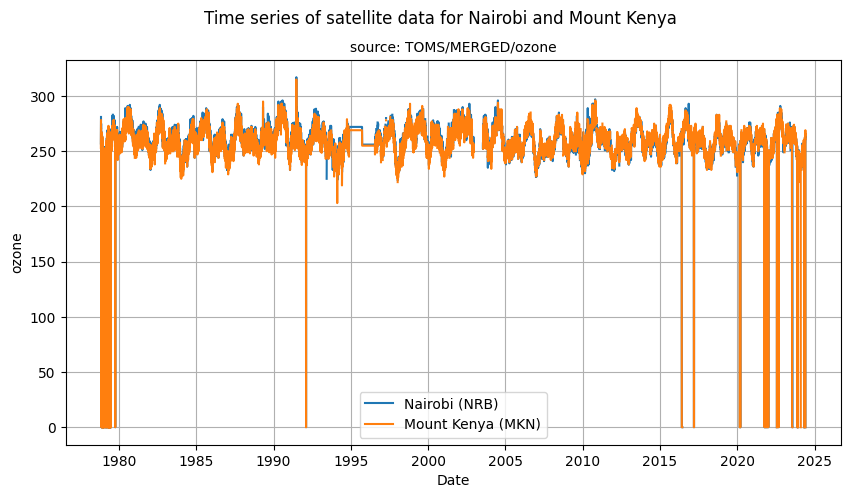

<Figure size 640x480 with 0 Axes>

In [5]:
# process specified collections
# collections_subset = ['COPERNICUS/S5P/NRTI/L3_O3_TCL','COPERNICUS/S5P/OFFL/L3_O3','COPERNICUS/S5P/OFFL/L3_O3_TCL']
collections_subset = ['TOMS/MERGED']
for collection in collections.keys():
    if collection in collections_subset:
        for variable in collections[collection]['variables']:
            process_collection(collection=collection, variable=variable)

In [ ]:
# process all available collections
# NB: This will take several hours or even days to complete!
for collection in collections.keys():
    for variable in collections[collection]['variables']:
        process_collection()